<a href="https://colab.research.google.com/github/Afrin-mte/OIBSIP/blob/main/Task_04(Dataset_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Sentiment Analysis On Play Store User Review**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [4]:
df = pd.read_csv("user_reviews.csv")
df.head()
print(df.shape)
df.info()
df.isnull().sum()

(64295, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


**Sentiment Distribution**

Dataset Shape after dropping null values: (37427, 6)

Class Distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


/tmp/ipykernel_1979/1830838415.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Sentiment', data=df, order=['Negative', 'Neutral', 'Positive'], palette='viridis')


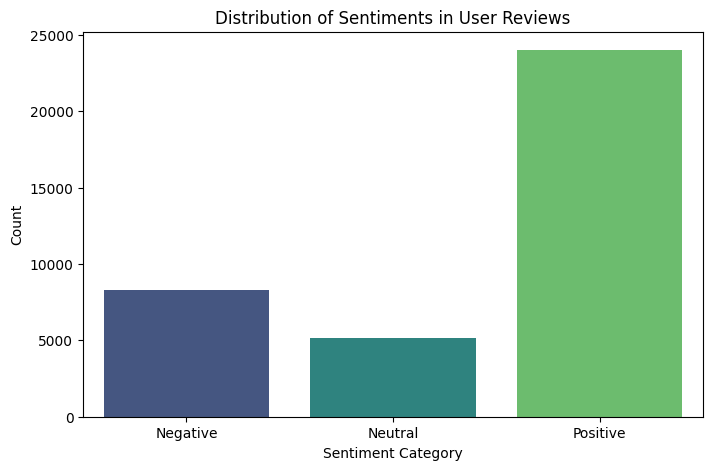

In [5]:
# Drop missing values in the text or sentiment label columns
df.dropna(subset=['Translated_Review', 'Sentiment'], inplace=True)
# Map text sentiments to numerical values for consistency
sentiment_mapping = {'Negative': -1, 'Neutral': 0, 'Positive': 1}
df['category'] = df['Sentiment'].map(sentiment_mapping)
print(f"Dataset Shape after dropping null values: {df.shape}")
print("\nClass Distribution:")
print(df['Sentiment'].value_counts())
# Visualization 1: Sentiment Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Sentiment', data=df, order=['Negative', 'Neutral', 'Positive'], palette='viridis')
plt.title('Distribution of Sentiments in User Reviews')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

**NLP Preprocessing**

In [8]:
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    text = str(text).lower() # Lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\@\w+|\#','', text) # Remove mentions and hashtags
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = " ".join([word for word in text.split() if word not in stop_words])
    return text

print("Applying NLP preprocessing on user reviews...")
df['processed_text'] = df['Translated_Review'].apply(preprocess_text)

X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'],
    df['category'],
    test_size=0.2,
    random_state=42,
    stratify=df['category']
)

Applying NLP preprocessing on user reviews...


**Feature Engineering**

In [9]:
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(f"Feature Engineering complete. Extracted {X_train_vec.shape[1]} features.")

Feature Engineering complete. Extracted 15000 features.


**Naive Bayes and Support Vector Machine (LinearSVC) models on the vectorized user reviews**

In [10]:
print("Training Naive Bayes Model...")
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
nb_pred = nb_model.predict(X_test_vec)
print("Training Support Vector Machine...")
svm_model = LinearSVC(max_iter=2000, random_state=42)
svm_model.fit(X_train_vec, y_train)
svm_pred = svm_model.predict(X_test_vec)
print("Models trained successfully!")

Training Naive Bayes Model...
Training Support Vector Machine...
Models trained successfully!


**Metrics and the confusion matrix for the SVM mode**

SVM Classification Report
              precision    recall  f1-score   support

    Negative       0.90      0.86      0.88      1654
     Neutral       0.85      0.86      0.86      1032
    Positive       0.94      0.95      0.95      4800

    accuracy                           0.92      7486
   macro avg       0.90      0.89      0.89      7486
weighted avg       0.92      0.92      0.92      7486



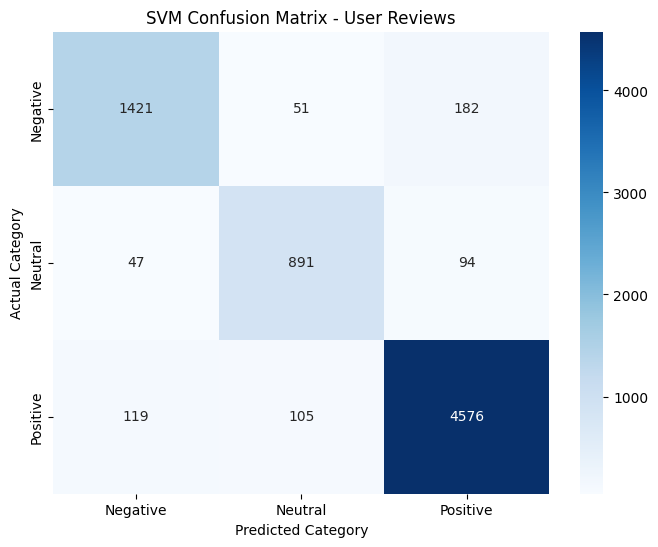

In [11]:
print("SVM Classification Report")
print(classification_report(y_test, svm_pred, target_names=['Negative', 'Neutral', 'Positive']))
cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('SVM Confusion Matrix - User Reviews')
plt.show()

**WordCloud Visualizations**

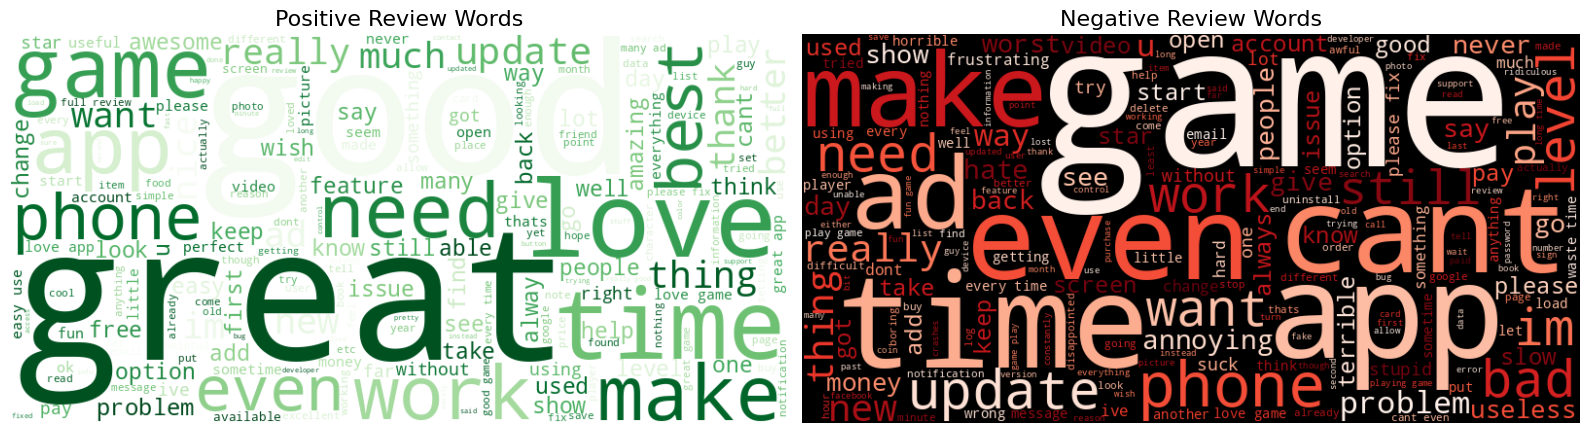

In [12]:
positive_text = " ".join(df[df['category'] == 1]['processed_text'])
negative_text = " ".join(df[df['category'] == -1]['processed_text'])
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)
ax[0].imshow(wordcloud_pos, interpolation='bilinear')
ax[0].set_title('Positive Review Words', fontsize=16)
ax[0].axis('off')

wordcloud_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)
ax[1].imshow(wordcloud_neg, interpolation='bilinear')
ax[1].set_title('Negative Review Words', fontsize=16)
ax[1].axis('off')

plt.tight_layout()
plt.show()